In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import math
import glob

import FileHelper

In [13]:
fileNames = glob.glob('/Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus*.root')
trainVarFile = '/Users/isobel/Desktop/DUNE/Ivysaurus/files/trainVarArrays.npz'
print(fileNames)

['/Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_1_nutau.root', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_1_nue.root', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_1_nu.root']


In [10]:
nClasses = 6

In [14]:
trackVarsSuccessful, nTrackChildren, nShowerChildren, nGrandChildren, nChildHits, childEnergy, childTrackScore, trackLength, trackWobble, trackScore, momComparison, particlePDG = FileHelper.readTrackVars(fileNames)

Reading tree:  /Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_1_nutau.root , This may take a while...
Reading tree:  /Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_1_nue.root , This may take a while...
Reading tree:  /Users/isobel/Desktop/DUNE/Ivysaurus/files/grid24/ivysaurus_1_nu.root , This may take a while...


In [15]:
print(nTrackChildren.shape)

(375634, 1)


In [16]:
particleColors = ('b', 'g', 'k', 'r', 'tab:orange', 'tab:gray')

# muons = 0, protons = 1, pions = 2, electrons = 3, photons = 4, other = 5
nMuons = np.count_nonzero(particlePDG == 0)    
nProtons = np.count_nonzero(particlePDG == 1)  
nPions = np.count_nonzero(particlePDG == 2)  
nElectrons = np.count_nonzero(particlePDG == 3)  
nPhotons = np.count_nonzero(particlePDG == 4)  
nOther = np.count_nonzero(particlePDG == 5) 

print('nMuons:', nMuons)
print('nProtons: ', nProtons)
print('nPions: ', nPions)
print('nElectrons: ', nElectrons)
print('nPhotons: ', nPhotons)
print('nOther: ', nOther)

nParticles = [nMuons, nProtons, nPions, nElectrons, nPhotons, nOther]

nMuons: 42920
nProtons:  105488
nPions:  89757
nElectrons:  37966
nPhotons:  99503
nOther:  0


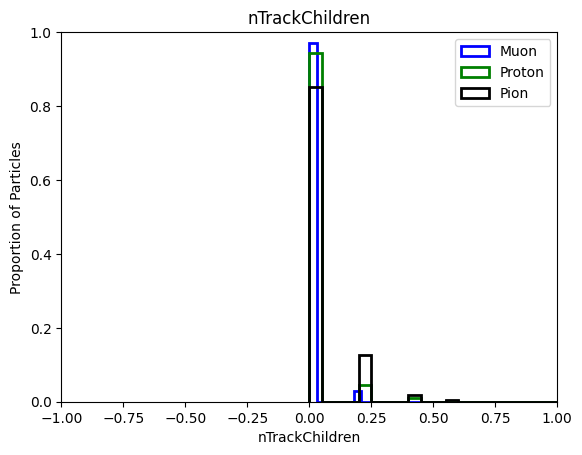

In [17]:
# Plot the track children
    
nTrackChildrenLimit = 5
    
for i in range(3) :

    thisNTrackChildren = nTrackChildren[particlePDG == i]
    
    thisNTrackChildren[thisNTrackChildren > nTrackChildrenLimit] = nTrackChildrenLimit
    thisNTrackChildren = thisNTrackChildren / nTrackChildrenLimit
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNTrackChildren, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-1.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('nTrackChildren')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('nTrackChildren')

plt.show()

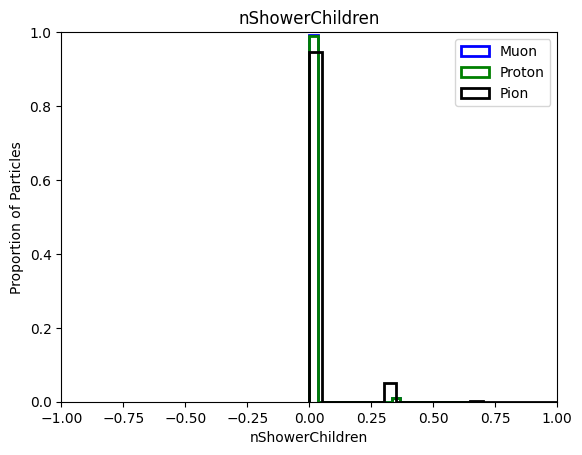

In [18]:
# Plot the shower children
    
nShowerChildrenLimit = 3   
    
for i in range(3) :

    thisNShowerChildren = nShowerChildren[particlePDG == i]
    
    thisNShowerChildren[thisNShowerChildren > nShowerChildrenLimit] = nShowerChildrenLimit
    thisNShowerChildren = thisNShowerChildren / nShowerChildrenLimit
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNShowerChildren, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-1.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('nShowerChildren')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('nShowerChildren')

plt.show()

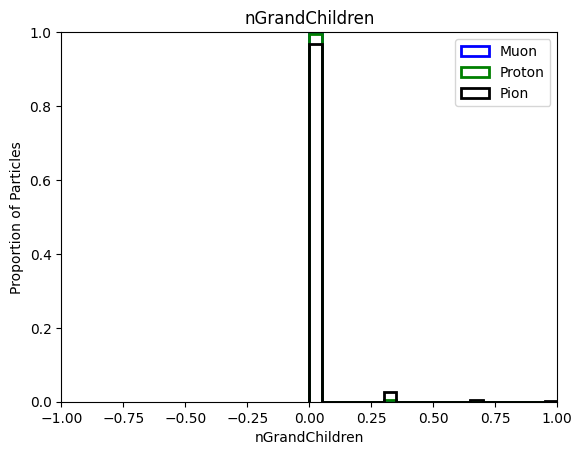

In [19]:
# Plot the grandchildren
    
nGrandChildrenLimit = 3    
    
for i in range(3) :

    thisNGrandChildren = nGrandChildren[particlePDG == i]
    
    thisNGrandChildren[thisNGrandChildren > nGrandChildrenLimit] = nGrandChildrenLimit
    thisNGrandChildren = thisNGrandChildren / nGrandChildrenLimit
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNGrandChildren, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-1.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('nGrandChildren')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('nGrandChildren')

plt.show()

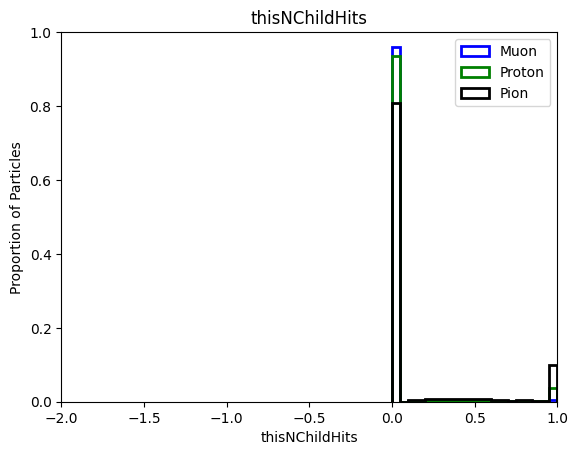

In [35]:
# Plot the child hits

nChildHitsLimitMin = -2
nChildHitsLimitMax = 100
    
for i in range(3) :

    thisNChildHits = nChildHits[particlePDG == i]
    
    thisNChildHits[thisNChildHits > nChildHitsLimitMax] = nChildHitsLimitMax
    thisNChildHits[thisNChildHits < nChildHitsLimitMin] = nChildHitsLimitMin
    thisNChildHits = thisNChildHits / nChildHitsLimitMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisNChildHits, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('thisNChildHits')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('thisNChildHits')

plt.show()

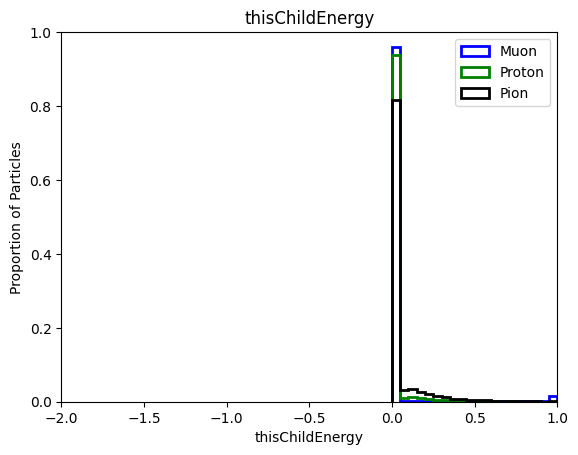

In [46]:
# Plot the child energy

childEnergyLimitMin = -2
childEnergyLimitMax = 1
    
for i in range(3) :

    thisChildEnergy = childEnergy[particlePDG == i]
    
    thisChildEnergy[thisChildEnergy > childEnergyLimitMax] = childEnergyLimitMax
    thisChildEnergy[thisChildEnergy < childEnergyLimitMin] = childEnergyLimitMin
    #thisChildEnergy = thisChildEnergy / childEnergyLimitMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisChildEnergy, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('thisChildEnergy')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('thisChildEnergy')

plt.show()

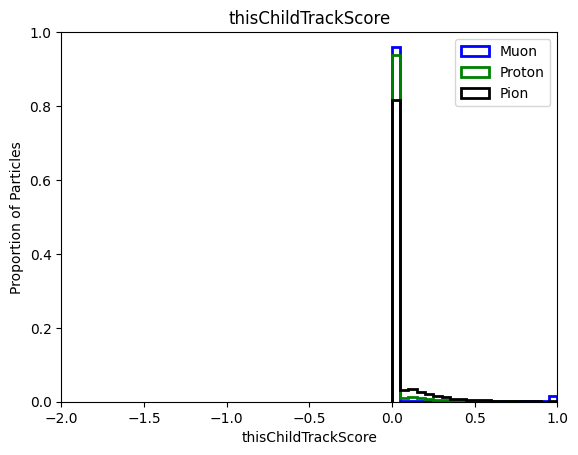

In [48]:
# Plot the child track score

print('THERE IS A PROBLEM WITH THIS VARIABLE')

childTrackScoreLimitMin = -2
childTrackScoreLimitMax = 1
    
for i in range(3) :

    thisChildTrackScore = childTrackScore[particlePDG == i]
    
    thisChildTrackScore[thisChildTrackScore > childTrackScoreLimitMax] = childTrackScoreLimitMax
    thisChildTrackScore[thisChildTrackScore < childTrackScoreLimitMin] = childTrackScoreLimitMin
    #thisChildEnergy = thisChildEnergy / childEnergyLimitMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisChildTrackScore, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('thisChildTrackScore')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('thisChildTrackScore')

plt.show()

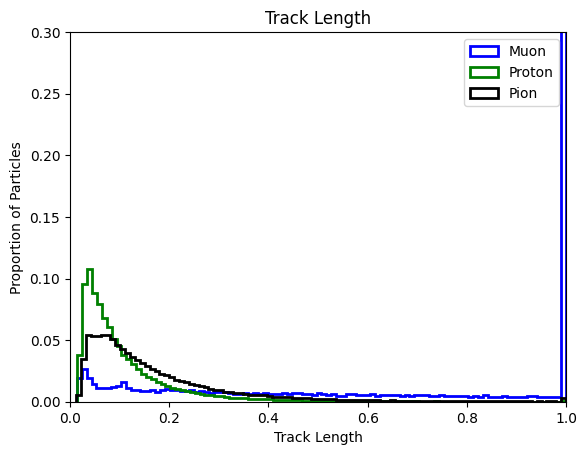

In [20]:
# Plot the track length
    
trackLengthLimit = 500.0    
    
for i in range(3) :

    thisTrackLength = trackLength[particlePDG == i]
    
    thisTrackLength[thisTrackLength > trackLengthLimit] = trackLengthLimit
    thisTrackLength = thisTrackLength / trackLengthLimit
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisTrackLength, bins=100, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([0, 1])
plt.ylim([0.0, 0.3])
plt.xlabel('Track Length')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('Track Length')

plt.show()

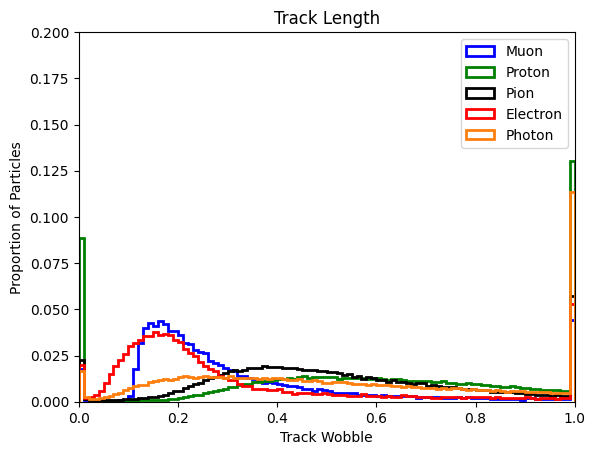

In [10]:
# Plot the track wobble
    
wobbleLimit = 15
    
for i in range(5) :

    thisTrackWobble = trackWobble[particlePDG == i]
    

    thisTrackWobble[thisTrackWobble > wobbleLimit] = wobbleLimit
    thisTrackWobble = thisTrackWobble / wobbleLimit
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisTrackWobble, bins=100, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([0, 1.0])
plt.ylim([0.0, 0.2])
plt.xlabel('Track Wobble')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('Track Length')

plt.show()

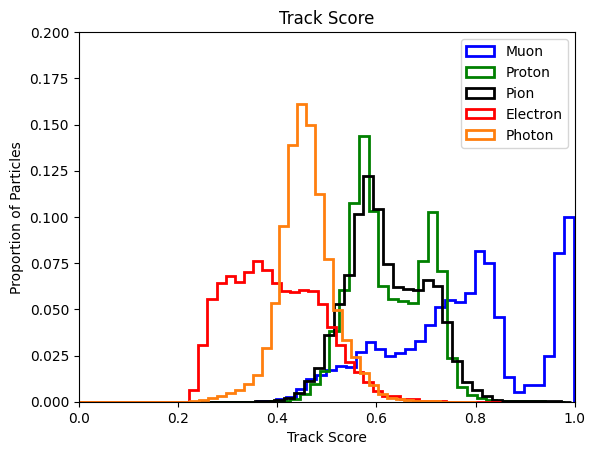

In [49]:
# Plot the track score
    
    
for i in range(5) :

    thisTrackScore = trackScore[particlePDG == i]
    
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisTrackScore, bins=100, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([0, 1.0])
plt.ylim([0.0, 0.2])
plt.xlabel('Track Score')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('Track Score')

plt.show()

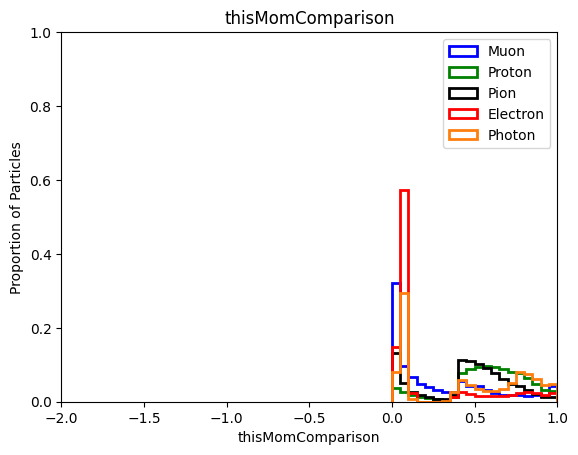

In [59]:
# Plot the track momentum comparison

momComparisonMin = -2
momComparisonMax = 10
    
for i in range(5) :

    thisMomComparison = momComparison[particlePDG == i]
    
    thisMomComparison[thisMomComparison > momComparisonMax] = momComparisonMax
    thisMomComparison[thisMomComparison < momComparisonMin] = momComparisonMin
    thisMomComparison = thisMomComparison / momComparisonMax
    
    weights = np.full(nParticles[i], 1.0/nParticles[i])
    plt.hist(thisMomComparison, bins=20, weights=weights, color=particleColors[i], histtype='step', linewidth=2)
    
plt.xlim([-2.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('thisMomComparison')
plt.ylabel('Proportion of Particles')
plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
plt.title('thisMomComparison')

plt.show()


In [26]:
jam = [4, 6, 2, 9, 1]
jam = np.array(jam)
jam = jam.reshape(jam.shape[0], 1)
frog = [44, 66, 22, 99, 11]
frog = np.array(frog)
frog = frog.reshape(frog.shape[0], 1)




In [27]:
together = np.concatenate((jam, frog), axis=1)
print(together)

[[ 4 44]
 [ 6 66]
 [ 2 22]
 [ 9 99]
 [ 1 11]]
